# Ejercicio 2: visualiza los datos

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# Ruta donde están los CSV
data_path = "Data/."

# Patrón para localizar todos los ficheros de entrenamiento
csv_files = glob.glob(os.path.join(data_path, "TankTraining_*.csv"))
print("Encontrados:", len(csv_files), "ficheros")
print("\n".join(csv_files))

Encontrados: 165 ficheros
Data/.\TankTraining_01_12_2025 16_53_57.csv
Data/.\TankTraining_01_12_2025 16_54_13.csv
Data/.\TankTraining_01_12_2025 16_55_15.csv
Data/.\TankTraining_01_12_2025 16_55_30.csv
Data/.\TankTraining_01_12_2025 16_55_50.csv
Data/.\TankTraining_01_12_2025 16_56_04.csv
Data/.\TankTraining_01_12_2025 17_08_25.csv
Data/.\TankTraining_01_12_2025 17_08_48.csv
Data/.\TankTraining_01_12_2025 17_12_39.csv
Data/.\TankTraining_01_12_2025 17_13_07.csv
Data/.\TankTraining_01_12_2025 17_13_31.csv
Data/.\TankTraining_01_12_2025 17_13_52.csv
Data/.\TankTraining_02_12_2025 10_45_19.csv
Data/.\TankTraining_02_12_2025 10_45_38.csv
Data/.\TankTraining_02_12_2025 10_45_55.csv
Data/.\TankTraining_02_12_2025 10_46_21.csv
Data/.\TankTraining_02_12_2025 10_46_35.csv
Data/.\TankTraining_02_12_2025 10_46_55.csv
Data/.\TankTraining_02_12_2025 10_47_11.csv
Data/.\TankTraining_02_12_2025 10_47_35.csv
Data/.\TankTraining_02_12_2025 10_47_50.csv
Data/.\TankTraining_02_12_2025 10_48_16.csv
Data/.

In [2]:
dfs = [pd.read_csv(f) for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Shape del dataset combinado:", data.shape)
data.head()

Shape del dataset combinado: (27300, 22)


,NEIGHBORHOOD_UP,NEIGHBORHOOD_DOWN,NEIGHBORHOOD_RIGHT,NEIGHBORHOOD_LEFT,NEIGHBORHOOD_DIST_UP,NEIGHBORHOOD_DIST_DOWN,NEIGHBORHOOD_DIST_RIGHT,NEIGHBORHOOD_DIST_LEFT,COMMAND_CENTER_X,COMMAND_CENTER_Y,...,AGENT_2_X,AGENT_2_Y,CAN_FIRE,HEALTH,LIFE_X,LIFE_Y,EXIT_X,EXIT_Y,time,action
0,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.122043,0.0
1,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.205221,0.0
2,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.303706,0.0
3,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.407916,0.0
4,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,0.0,2.0,11.0,5.0,3.0,21.0,0.501813,0.0


In [3]:
action_counts = data["action"].value_counts().sort_index()
print(action_counts)

action
0.0    3748
1.0    9146
2.0    1846
3.0    6917
4.0    5478
Name: count, dtype: int64


In [4]:
# Eliminar filas donde 'action' sea NaN
data = data.dropna(subset=["action"]).copy()

# Ahora sí podemos castear a int sin problemas
data["action_int"] = data["action"].astype(int)

action_names = {
    0: "NOTHING",
    1: "MOVE_UP",
    2: "MOVE_DOWN",
    3: "MOVE_RIGHT",
    4: "MOVE_LEFT",
}

data["action_int"] = data["action"].astype(int)
data["action_name"] = data["action_int"].map(action_names)

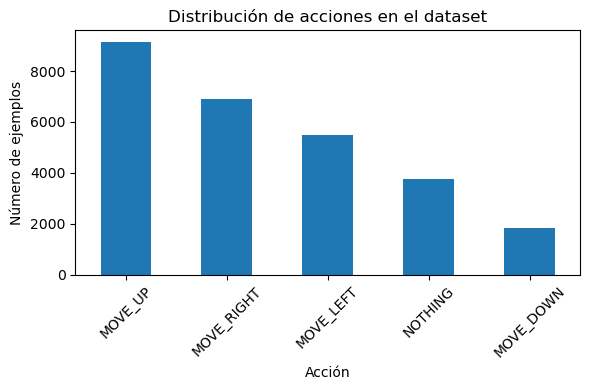

In [5]:
plt.figure(figsize=(6,4))
action_counts = data["action_name"].value_counts()

action_counts.plot(kind="bar")
plt.xlabel("Acción")
plt.ylabel("Número de ejemplos")
plt.title("Distribución de acciones en el dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features: todo menos 'action' y la columna auxiliar 'action_int'
X = data.drop(columns=["action", "action_int", "action_name"])
y = data["action_int"]
print("Shape X:", X.shape)

Shape X: (27135, 21)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:",
      pca.explained_variance_ratio_)

Varianza explicada por PC1 y PC2: [0.23231074 0.10261241]


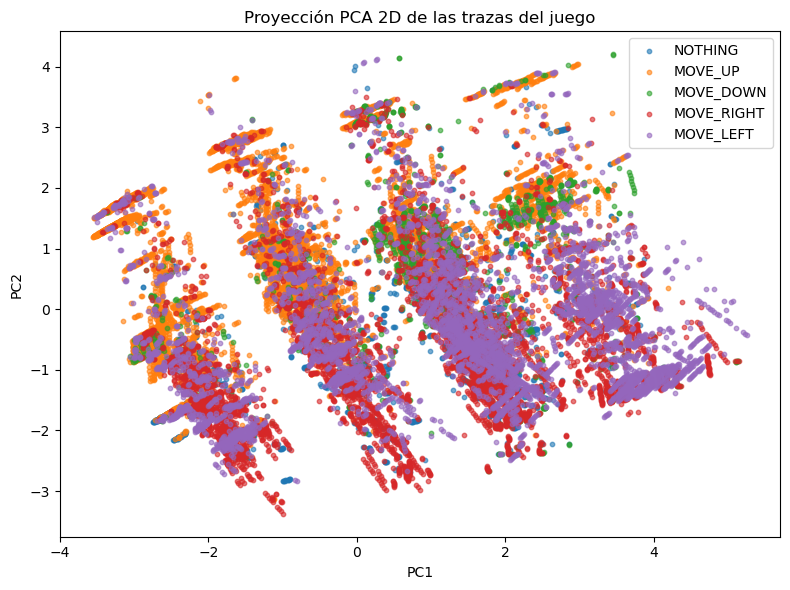

In [9]:
plt.figure(figsize=(8,6))

for action_value, name in action_names.items():
    idx = (y == action_value)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.6,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA 2D de las trazas del juego")
plt.legend()
plt.tight_layout()
plt.show()

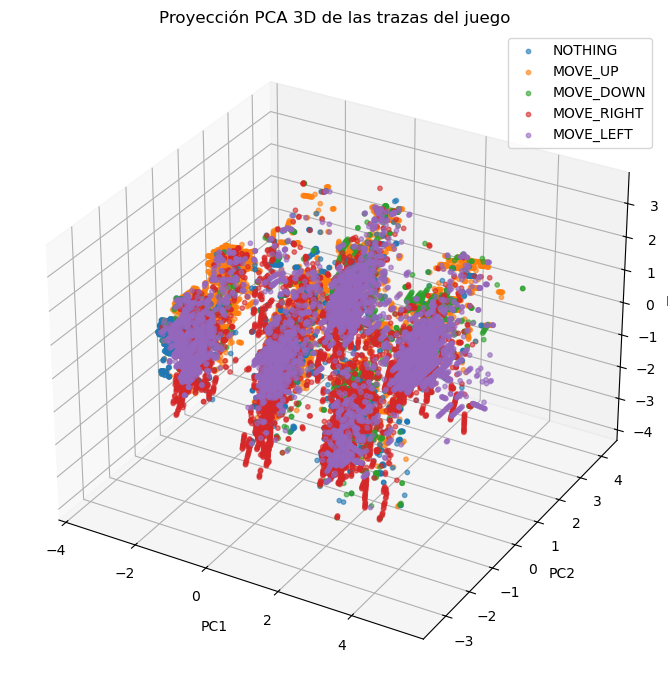

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # import necesario

pca3 = PCA(n_components=3, random_state=0)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for action_value, name in action_names.items():
    idx = (y == action_value)
    ax.scatter(
        X_pca3[idx, 0],
        X_pca3[idx, 1],
        X_pca3[idx, 2],
        s=10,
        alpha=0.6,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Proyección PCA 3D de las trazas del juego")
ax.legend()
plt.tight_layout()
plt.show()


# Ejercicio 3: limpia el dataset

In [11]:
df = data.dropna().copy()

# Se aseguran tipos numéricos en los vecinos
for col in ["NEIGHBORHOOD_UP", "NEIGHBORHOOD_DOWN",
            "NEIGHBORHOOD_RIGHT", "NEIGHBORHOOD_LEFT"]:
    df[col] = pd.to_numeric(df[col])

# Acción como entero (0..4)
df["action_int"] = df["action"].astype(int)

In [12]:
cols_to_drop = [c for c in ["action_name"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "NEIGHBORHOOD_UP",
    "NEIGHBORHOOD_DOWN",
    "NEIGHBORHOOD_RIGHT",
    "NEIGHBORHOOD_LEFT",
]

# numeric_cols: todas las numéricas excepto acción y los vecinos (que van por OHE)
numeric_cols = [
    c for c in df.columns
    if c not in categorical_cols + ["action", "action_int"]
]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['NEIGHBORHOOD_UP', 'NEIGHBORHOOD_DOWN', 'NEIGHBORHOOD_RIGHT', 'NEIGHBORHOOD_LEFT']
Numeric: ['NEIGHBORHOOD_DIST_UP', 'NEIGHBORHOOD_DIST_DOWN', 'NEIGHBORHOOD_DIST_RIGHT', 'NEIGHBORHOOD_DIST_LEFT', 'COMMAND_CENTER_X', 'COMMAND_CENTER_Y', 'AGENT_1_X', 'AGENT_1_Y', 'AGENT_2_X', 'AGENT_2_Y', 'CAN_FIRE', 'HEALTH', 'LIFE_X', 'LIFE_Y', 'EXIT_X', 'EXIT_Y', 'time']


In [14]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[categorical_cols])

# Numéricas como array float
X_num = df[numeric_cols].to_numpy(dtype=float)

# Dataset de entrada completo
import numpy as np
X_full = np.hstack([X_cat, X_num])

# Etiquetas
y = df["action_int"].to_numpy()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.33,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (18180, 38)  Test: (8955, 38)


In [16]:
import pandas as pd
import numpy as np

# 1) Nombres de las columnas one-hot
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

# 2) DataFrames separados
X_cat_df = pd.DataFrame(X_cat, columns=cat_feature_names, index=df.index)
X_num_df = df[numeric_cols].astype(float).reset_index(drop=True)

# 3) Dataset de entrada completo como DataFrame
X_full_df = pd.concat([X_cat_df.reset_index(drop=True), X_num_df], axis=1)

print("Shape X_full_df:", X_full_df.shape)

Shape X_full_df: (27135, 38)


In [17]:
X_full = X_full_df.to_numpy()
y = df["action_int"].to_numpy()

In [18]:
df_clean = X_full_df.copy()
df_clean["action_int"] = y


df_clean.to_csv("TankTraining_clean_OHE.csv", index=False)

# Ejercicio 4: prueba diferentes modelos de Machine Learning

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset ya limpio + OHE
df_ohe = pd.read_csv("TankTraining_clean_OHE.csv")

# X: todas las columnas menos la etiqueta
X = df_ohe.drop(columns=["action_int"]).to_numpy(dtype=float)
y = df_ohe["action_int"].to_numpy(dtype=int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases:", np.unique(y))

X shape: (27135, 38)
y shape: (27135,)
Clases: [0 1 2 3 4]


In [20]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train.shape, X_test.shape

((21708, 38), (5427, 38))

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Baseline: 2 capas ocultas (por ejemplo 64 y 32 neuronas)
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="logistic",
    solver="adam",
    alpha=1e-6,
    learning_rate_init=0.005,
    max_iter=2000,
    random_state=0
)

mlp_sklearn.fit(X_train, y_train)

y_train_pred = mlp_sklearn.predict(X_train)
y_test_pred = mlp_sklearn.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"MLP sklearn (logistic) - Acc train: {acc_train:.3f} Acc test: {acc_test:.3f}")

MLP sklearn (logistic) - Acc train: 0.881 Acc test: 0.784


In [22]:
import numpy as np
from MLP import MLP

n_classes = len(np.unique(y_train))

Y_train_oh = np.eye(n_classes)[y_train] # (N_train, 5)
Y_test_oh = np.eye(n_classes)[y_test]   # (N_test, 5)

In [23]:
input_dim = X_train.shape[1]
hidden_dim = 25
output_dim = n_classes

mlp_own = MLP(input_dim, hidden_dim, output_dim, seed=0, epislom=0.12)

Jhistory = mlp_own.backpropagation(
    X_train,
    Y_train_oh,
    alpha=1.0,
    lambda_=0.0,
    numIte=2000,
    verbose=200
)

Iteration      1: Cost   3.4319   
Iteration    201: Cost   1.6436   
Iteration    401: Cost   1.5645   
Iteration    601: Cost   1.4899   
Iteration    801: Cost   1.4324   
Iteration   1001: Cost   1.3906   
Iteration   1201: Cost   1.3608   
Iteration   1401: Cost   1.3394   
Iteration   1601: Cost   1.3234   
Iteration   1801: Cost   1.3109   
Iteration   2000: Cost   1.3006   


In [24]:
from sklearn.metrics import accuracy_score

# Train
a3_train = mlp_own.feedforward(X_train)[2]
y_train_pred_own = mlp_own.predict(a3_train)

# Test
a3_test = mlp_own.feedforward(X_test)[2]
y_test_pred_own = mlp_own.predict(a3_test)

acc_train_own = accuracy_score(y_train, y_train_pred_own)
acc_test_own = accuracy_score(y_test, y_test_pred_own)

print(f"MLP propio - Acc train: {acc_train_own:.3f}   Acc test: {acc_test_own:.3f}")

MLP propio - Acc train: 0.738   Acc test: 0.718


### MLPClassifier "tuneado"

In [25]:
mlp_relu = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=400,
    random_state=0,
    early_stopping=True,
    n_iter_no_change=10
)

mlp_relu.fit(X_train, y_train)
y_test_pred_relu = mlp_relu.predict(X_test)
acc_test_relu = accuracy_score(y_test, y_test_pred_relu)
print(f"MLP sklearn (ReLU) - Acc test: {acc_test_relu:.3f}")

MLP sklearn (ReLU) - Acc test: 0.762


### KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    p=2
)

knn.fit(X_train, y_train)
y_test_pred_knn = knn.predict(X_test)
acc_test_knn = accuracy_score(y_test, y_test_pred_knn)
print(f"KNN (k=7) - Acc test: {acc_test_knn:.3f}")

KNN (k=7) - Acc test: 0.808


### Árbol de decisión y Random Forest

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree_clf = DecisionTreeClassifier(
    max_depth=20,
    min_samples_leaf=5,
    random_state=0
)

tree_clf.fit(X_train, y_train)
y_test_pred_tree = tree_clf.predict(X_test)
acc_test_tree = accuracy_score(y_test, y_test_pred_tree)
print(f"Decision Tree - Acc test: {acc_test_tree:.3f}")

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=0,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
y_test_pred_rf = rf_clf.predict(X_test)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Random Forest - Acc test: {acc_test_rf:.3f}")

Decision Tree - Acc test: 0.792
Random Forest - Acc test: 0.846


### Matrices de confusión + métricas para todos los modelos

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

action_names = {
    0: "NOTHING",
    1: "MOVE_UP",
    2: "MOVE_DOWN",
    3: "MOVE_RIGHT",
    4: "MOVE_LEFT",
}
labels_order = [0,1,2,3,4]
display_labels = [action_names[i] for i in labels_order]

def eval_and_report(name, y_true, y_pred):
    print("="*60)
    print(name)
    print("="*60)
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=display_labels))
    
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(xticks_rotation=45)

MLP
Accuracy: 0.718

Classification report:
              precision    recall  f1-score   support

     NOTHING       0.68      0.47      0.56       750
     MOVE_UP       0.77      0.83      0.80      1829
   MOVE_DOWN       0.66      0.36      0.47       369
  MOVE_RIGHT       0.70      0.79      0.74      1383
   MOVE_LEFT       0.68      0.74      0.71      1096

    accuracy                           0.72      5427
   macro avg       0.70      0.64      0.65      5427
weighted avg       0.71      0.72      0.71      5427

MLP sklearn (logistic)
Accuracy: 0.784

Classification report:
              precision    recall  f1-score   support

     NOTHING       0.73      0.74      0.73       750
     MOVE_UP       0.85      0.82      0.84      1829
   MOVE_DOWN       0.70      0.57      0.63       369
  MOVE_RIGHT       0.77      0.80      0.78      1383
   MOVE_LEFT       0.75      0.81      0.78      1096

    accuracy                           0.78      5427
   macro avg       0.76 

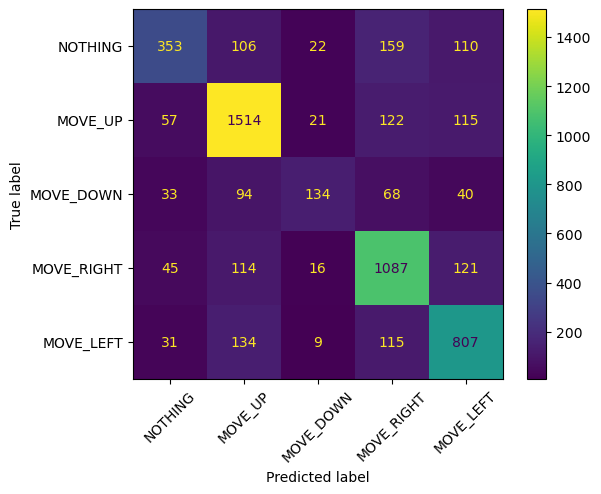

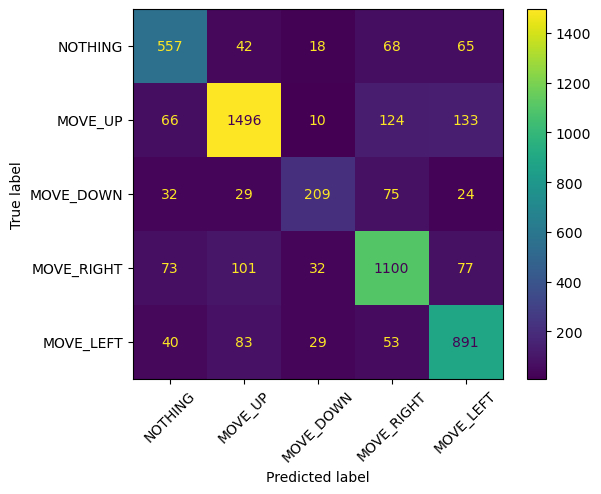

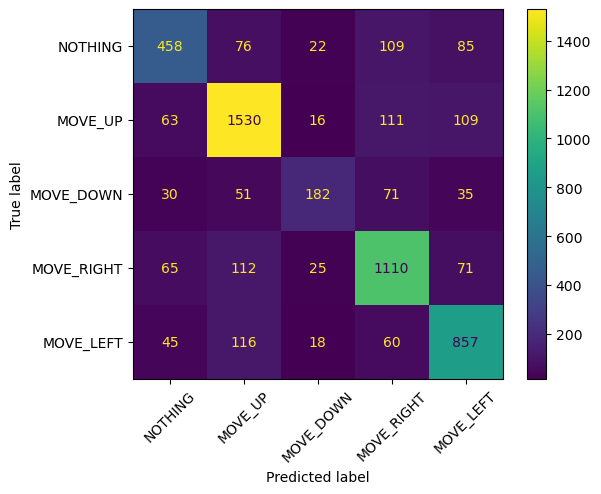

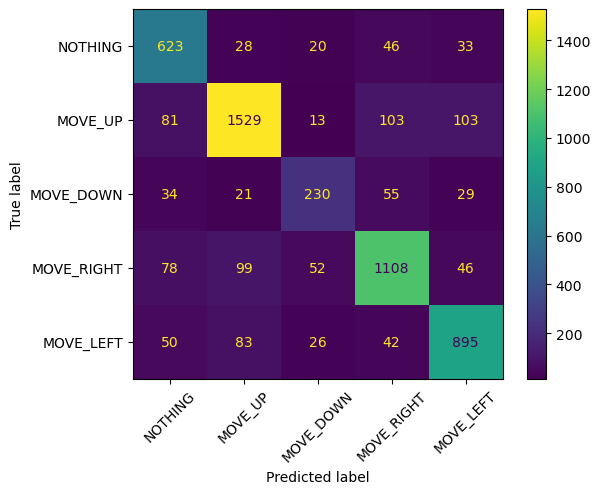

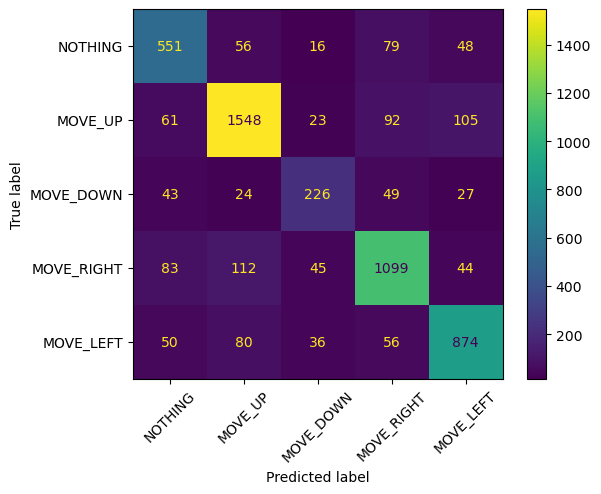

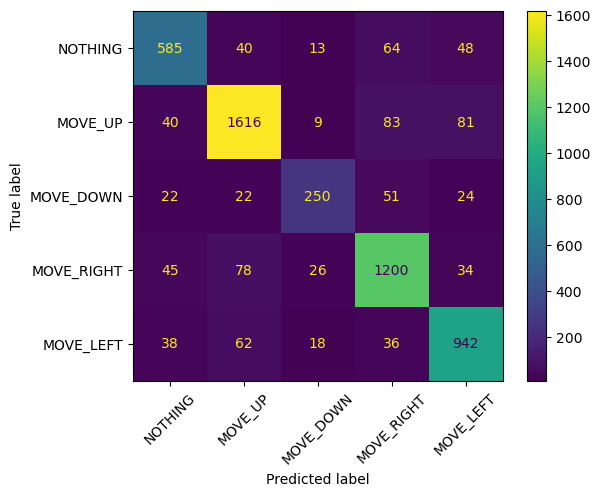

In [29]:
eval_and_report("MLP", y_test, y_test_pred_own)
eval_and_report("MLP sklearn (logistic)", y_test, y_test_pred)
eval_and_report("MLP sklearn (ReLU tuneado)", y_test, y_test_pred_relu)
eval_and_report("KNN", y_test, y_test_pred_knn)
eval_and_report("Decision Tree", y_test, y_test_pred_tree)
eval_and_report("Random Forest", y_test, y_test_pred_rf)

# Ejercicio 5: implementa el perceptrón multicapa que quieras en Unity

### Preparar y exportar el MLP final en Python

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("TankTraining_clean_OHE.csv")

dirs = ["NEIGHBORHOOD_UP", "NEIGHBORHOOD_DOWN", "NEIGHBORHOOD_RIGHT", "NEIGHBORHOOD_LEFT"]

for d in dirs:
    for k in range(11):
        col = f"{d}_{k}"
        if col not in df.columns:
            df[col] = 0.0

ohe_cols = []
for d in dirs:
    ohe_cols += [f"{d}_{k}" for k in range(11)]

num_cols = [
    "NEIGHBORHOOD_DIST_UP","NEIGHBORHOOD_DIST_DOWN","NEIGHBORHOOD_DIST_RIGHT","NEIGHBORHOOD_DIST_LEFT",
    "COMMAND_CENTER_X","COMMAND_CENTER_Y",
    "AGENT_1_X","AGENT_1_Y","AGENT_2_X","AGENT_2_Y",
    "CAN_FIRE","HEALTH","LIFE_X","LIFE_Y","EXIT_X","EXIT_Y",
    "time"
]

X_cols = ohe_cols + num_cols
X_all = df[X_cols].to_numpy(dtype=float)
y_all = df["action_int"].to_numpy(dtype=int)

print("X_all:", X_all.shape)

X_all: (27135, 61)


### Exportar el MLP y el StandardScaler

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from Utils import WriteStandardScaler, ExportAllformatsMLPSKlearn
import os

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

mlp_final = MLPClassifier(
    hidden_layer_sizes=(150,),
    activation="logistic",
    solver="adam",
    alpha=1e-6,
    learning_rate_init=0.005,
    max_iter=2000,
    random_state=0
)
mlp_final.fit(X_all_scaled, y_all)

output_dir = "Assets/Exports"
os.makedirs(output_dir, exist_ok=True)

# Exporta scaler
WriteStandardScaler(os.path.join(output_dir, "StandardScalerData.txt"),
                    scaler.mean_, scaler.var_)

# Exporta modelo
ExportAllformatsMLPSKlearn(
    mlp_final,
    X_all_scaled,
    os.path.join(output_dir, "TankMLP.pkl"),
    os.path.join(output_dir, "TankMLP.onnx"),
    os.path.join(output_dir, "TankMLP.json"),
    os.path.join(output_dir, "TankMLP_custom.txt")
)

Capa  coefficient
procesando  coefficient
['61', '150']
coefficient
[0.6388854522386155, 3.560675425834008, -1.752745571331793, 0.8490499790315378, 1.8977660994496692, -1.5254461440019236, 2.1634864447133304, 6.85300225831651, 1.3421612146641135, 1.2734848929585003, 1.5079596148448582, 3.1590630201782415, 3.813297871041139, 0.8778345014878004, -5.508521127313881, -0.0850903016626972, -4.058880396030535, -3.6587281556834177, 1.8647190795712723, 1.0505498402371487, 0.7170933891896238, 1.2370216362047122, 4.259858144081586, -1.0063212685521066, -0.45843112615615284, -0.6331396187287434, -3.622004101711049, 0.4648038808350304, -0.51638514290571, 0.8536196345749428, -0.5486406487456211, 0.7296674025933895, 5.535853887314963, -3.2407011343775354, 4.640210921542409, 0.632459640667798, 1.6813774137057196, 1.4857444550753294, 2.6878973354951645, 1.9690971919453066, -1.4440557458887189, -2.203526031218321, -0.9509866950642473, -1.2659188163081998, 3.25937027462702, -1.5213098951297477, 0.3962599

# Ejercicio 6

## Imports y parámetros

In [33]:
import zipfile, io
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from Utils import ExportAllformatsMLPSKlearn, WriteStandardScaler

K = 4  # ventana temporal (misma que pongas en Unity)

## Cargar partidas

In [36]:
from pathlib import Path
import pandas as pd

data_dir = Path("Data")   # carpeta donde están los CSV (relativa al notebook)
csv_paths = sorted(data_dir.rglob("*.csv"))  # rglob -> busca también en subcarpetas

def load_episode_df(path: Path):
    df = pd.read_csv(path)

    # unifica nombre de columna de acción
    if "action" not in df.columns and "action_int" in df.columns:
        df = df.rename(columns={"action_int": "action"})

    # la última fila "win/game over" suele dejar action no numérica -> la filtramos
    df["action"] = pd.to_numeric(df["action"], errors="coerce")
    df = df[df["action"].notna()].copy()
    df["action"] = df["action"].astype(int)

    # resto de columnas a numérico + limpiar NaNs
    for c in df.columns:
        if c != "action":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna()

    return df

episodes = []
for p in csv_paths:
    try:
        episodes.append(load_episode_df(p))
    except Exception as e:
        print("Saltando", p.name, "->", e)

print("CSV encontrados:", len(csv_paths))
print("Episodios cargados:", len(episodes))
print("Ejemplo shape:", episodes[0].shape if episodes else None)

CSV encontrados: 165
Episodios cargados: 165
Ejemplo shape: (172, 22)


In [37]:
## One-Hot Encoding exactamente como el juego

In [38]:
cat_cols = ["NEIGHBORHOOD_UP","NEIGHBORHOOD_DOWN","NEIGHBORHOOD_RIGHT","NEIGHBORHOOD_LEFT"]

num_cols = [
    "NEIGHBORHOOD_DIST_UP","NEIGHBORHOOD_DIST_DOWN","NEIGHBORHOOD_DIST_RIGHT","NEIGHBORHOOD_DIST_LEFT",
    "COMMAND_CENTER_X","COMMAND_CENTER_Y",
    "AGENT_1_X","AGENT_1_Y","AGENT_2_X","AGENT_2_Y",
    "CAN_FIRE","HEALTH",
    "LIFE_X","LIFE_Y",
    "EXIT_X","EXIT_Y",
    "time"
]

# OHE fijo (para que siempre saque 11 por dirección)
ohe = OneHotEncoder(
    categories=[np.arange(11)]*4,
    sparse_output=False,
    handle_unknown="ignore"
)
ohe.fit(np.zeros((1,4)))  # fit dummy, categorías ya fijadas

def episode_to_Xy(df):
    X_cat = ohe.transform(df[cat_cols].to_numpy())
    X_num = df[num_cols].to_numpy(dtype=float)
    X = np.hstack([X_cat, X_num])     # D = 4*11 + 17 = 61
    y = df["action"].to_numpy(dtype=int)
    return X, y

In [39]:
## Construir la ventana temporal

In [40]:
def make_temporal(X, y, K):
    n, D = X.shape
    if n < K:
        return None, None

    Xw = np.zeros((n - K + 1, D * K), dtype=float)
    yw = y[K-1:].copy()

    for i in range(K-1, n):
        row = i - (K-1)
        for k in range(K):
            # k=0 → frame actual (t), k=1 → t-1, ...
            Xw[row, k*D:(k+1)*D] = X[i-k]
    return Xw, yw

X_list, y_list = [], []
for df in episodes:
    X, y = episode_to_Xy(df)
    Xw, yw = make_temporal(X, y, K)
    if Xw is not None:
        X_list.append(Xw)
        y_list.append(yw)

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)

print("X_all:", X_all.shape, "y_all:", y_all.shape)  # debería ser (N, 61*K)

X_all: (26640, 244) y_all: (26640,)


In [41]:
## Escalar + entrenar + exportar

In [42]:
# Escalado FINAL (sobre TODO)
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# (Opcional) Validación rápida
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_scaled, y_all,
    test_size=0.33,
    random_state=0,
    stratify=y_all
)

mlp = MLPClassifier(
    hidden_layer_sizes=(256,128,64),   # puedes empezar aquí
    activation="logistic",
    solver="adam",
    alpha=1e-6,
    learning_rate_init=0.005,
    max_iter=2000,
    random_state=0
)
mlp.fit(X_tr, y_tr)
print("Acc val:", mlp.score(X_te, y_te))

# Reentrena con todo para export final
mlp.fit(X_all_scaled, y_all)

output_dir = "Assets/Exports"

WriteStandardScaler(f"{output_dir}/StandardScalerData_TW{K}.txt", scaler.mean_, scaler.var_)

ExportAllformatsMLPSKlearn(
    mlp,
    X_all_scaled,
    f"{output_dir}/TankMLP_TW{K}.pkl",
    f"{output_dir}/TankMLP_TW{K}.onnx",
    f"{output_dir}/TankMLP_TW{K}.json",
    f"{output_dir}/TankMLP_TW{K}_custom.txt"
)

print("Export listo en:", output_dir)


Acc val: 0.805277525022748
Capa  coefficient
procesando  coefficient
['244', '256']
coefficient
[0.20539482402406353, -0.7704947515458083, -0.7087697258025288, 0.7462699270336949, -1.0361187362959072, 0.8401259400530201, 0.7320063345812277, -0.32893983934091275, 0.6914767117434524, -0.18766958774952908, 0.9049899984141325, -1.078828915937528, 1.0873754386290622, 0.6559422646516648, -1.3725817659057766, -0.2598355218316067, 2.0548293061590983, 2.853749493756806, -0.03659627544416552, 0.1611396251663011, -0.17566311832451167, -0.8168523077212975, 0.12760047609224867, 2.127964242706062, 0.502445729750613, 0.5105879098753866, 1.5376772517405446, 0.579380673427549, 0.29997151549779816, 1.0916483209077976, 0.7730399999033221, 0.6174794807010211, -0.38103864575655605, -0.6701524434370991, 0.19521588572232154, 2.417849738962757, 1.2252674090768125, -0.03974953100029277, 0.6371471489013819, 1.5632083927658673, 0.10140951253368986, 1.5185915793847502, -0.4474404405793493, -0.4412856567640526, 0.